# LLM Fine-Tuning on Jane Austen Text
Author: Rucha Abhay Panhale

### Overview
In this project, I will fine-tune a pre-trained language model (distilgpt2) on a subset of Jane Austen’s novels from Project Gutenberg.  
The goal is not to memorize facts but to adapt the model’s writing style to resemble Jane Austen’s narrative and dialogue patterns. Basically to write like her.

The performance of the fine-tuned model is evaluated by comparing text generations from:
- the original pre-trained model
- the fine-tuned model  
using the same prompts.


In [ ]:
!pip install -q transformers datasets accelerate sentencepiece

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset, Dataset, DatasetDict
import random
import numpy as np
import math
import matplotlib.pyplot as plt


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
r_seed = 42
random.seed(r_seed)
np.random.seed(r_seed)
torch.manual_seed(r_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(r_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

r_seed

42

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Download & Clean Jane Austen Texts


In [ ]:
!mkdir -p data_raw

In [ ]:
!wget -O data_raw/pride_prejudice.txt https://www.gutenberg.org/files/1342/1342-0.txt

--2026-03-29 01:57:46--  https://www.gutenberg.org/files/1342/1342-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 738046 (721K) [text/plain]
Saving to: ‘data_raw/pride_prejudice.txt’

data_raw/pride_prej 100%[===================>] 720.75K   641KB/s    in 1.1s    

2026-03-29 01:57:51 (641 KB/s) - ‘data_raw/pride_prejudice.txt’ saved [738046/738046]



In [ ]:
!wget -O data_raw/sense_sensibility.txt https://www.gutenberg.org/files/161/161-0.txt

--2026-03-29 01:57:51--  https://www.gutenberg.org/files/161/161-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 712924 (696K) [text/plain]
Saving to: ‘data_raw/sense_sensibility.txt’

data_raw/sense_sens 100%[===================>] 696.21K   621KB/s    in 1.1s    

2026-03-29 01:57:54 (621 KB/s) - ‘data_raw/sense_sensibility.txt’ saved [712924/712924]



In [ ]:
!wget -O data_raw/emma.txt https://www.gutenberg.org/files/158/158-0.txt

--2026-03-29 01:57:54--  https://www.gutenberg.org/files/158/158-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 897581 (877K) [text/plain]
Saving to: ‘data_raw/emma.txt’

data_raw/emma.txt   100%[===================>] 876.54K   653KB/s    in 1.3s    

2026-03-29 01:57:57 (653 KB/s) - ‘data_raw/emma.txt’ saved [897581/897581]



In [ ]:
!wget -O data_raw/persuasion.txt https://www.gutenberg.org/files/105/105-0.txt

--2026-03-29 01:57:57--  https://www.gutenberg.org/files/105/105-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 477866 (467K) [text/plain]
Saving to: ‘data_raw/persuasion.txt’

data_raw/persuasion 100%[===================>] 466.67K   420KB/s    in 1.1s    

2026-03-29 01:58:01 (420 KB/s) - ‘data_raw/persuasion.txt’ saved [477866/477866]



In [ ]:
import re

In [ ]:
def strip_gutenberg_header_footer(text):

  # Identify the start of main text
    start_phrases = [
        "*** START OF THIS PROJECT GUTENBERG EBOOK",
        "***START OF THIS PROJECT GUTENBERG EBOOK",
        "*** START OF THE PROJECT GUTENBERG EBOOK",
        "***START OF THE PROJECT GUTENBERG EBOOK",
        "*** START OF",
    ]

    start_idx = -1
    for phrase in start_phrases:
        if phrase in text:
            start_idx = text.find(phrase)
            # Skip the header line
            start_idx = text.find("\n", start_idx) + 1
            break

    if start_idx == -1:
        start_idx = 0  # fallback: keep from the beginning

    # Identify the end of main text
    end_phrases = [
        "*** END OF THIS PROJECT GUTENBERG EBOOK",
        "***END OF THIS PROJECT GUTENBERG EBOOK",
        "*** END OF THE PROJECT GUTENBERG EBOOK",
        "***END OF THE PROJECT GUTENBERG EBOOK",
        "*** END OF",
    ]

    end_idx = -1
    for phrase in end_phrases:
        if phrase in text:
            end_idx = text.find(phrase)
            break

    if end_idx == -1:
        end_idx = len(text)  # fallback: keep to end

    cleaned = text[start_idx:end_idx]
    return cleaned.strip()


In [ ]:
import os
os.makedirs("data_raw", exist_ok = True)
os.makedirs("data_clean", exist_ok = True)

###Cleaning Pride and Prejudice

In [ ]:
raw_path_pp = "data_raw/pride_prejudice.txt" #raw text file
clean_path_pp = "data_clean/pride_prejudice.txt" #cleaned text file

with open(raw_path_pp, "r", encoding="utf-8") as f:
  raw_pp = f.read()

clean_pp = strip_gutenberg_header_footer(raw_pp)

with open(clean_path_pp, "w", encoding="utf-8") as f:
  f.write(clean_pp)

len(raw_pp), len(clean_pp)

(728846, 728713)

In [ ]:
books = ["sense_sensibility", "emma", "persuasion"]

for name in books:
    raw_path = f"data_raw/{name}.txt"
    clean_path = f"data_clean/{name}.txt"

    with open(raw_path, "r", encoding="utf-8") as f:
        raw_txt = f.read()

    clean_txt = strip_gutenberg_header_footer(raw_txt)

    with open(clean_path, "w", encoding="utf-8") as f:
        f.write(clean_txt)

    print(name, "raw:", len(raw_txt), "clean:", len(clean_txt))


sense_sensibility raw: 690132 clean: 670674
emma raw: 880526 clean: 880423
persuasion raw: 464926 clean: 464827


In [ ]:
#combining all cleaned texts into one big corpus
clean_books = ["pride_prejudice", "sense_sensibility", "emma", "persuasion"]

full_corpus = ""

for book in clean_books:
    with open(f"data_clean/{book}.txt", "r", encoding="utf-8") as f:
        text = f.read().strip()
        full_corpus += text + "\n\n"   #adding space between books

#checking length
total_length = len(full_corpus)
print(total_length)


2744645


In [ ]:
!ls -l data_clean



total 2732
-rw-r--r-- 1 root root 897478 Mar 29 01:58 emma.txt
-rw-r--r-- 1 root root 469406 Mar 29 01:58 persuasion.txt
-rw-r--r-- 1 root root 737913 Mar 29 01:58 pride_prejudice.txt
-rw-r--r-- 1 root root 680410 Mar 29 01:58 sense_sensibility.txt


###Splitting into training, validation and test set

In [ ]:
total_length = len(full_corpus)

train_ratio = 0.8
valid_ratio = 0.1
test_ratio = 0.1

train_end = int(train_ratio * total_length)
valid_end = int((train_ratio +valid_ratio) * total_length)

train_split = full_corpus[:train_end]
valid_split = full_corpus[train_end:valid_end]
test_split = full_corpus[valid_end:]

len(train_split), len(valid_split), len(test_split), total_length

(2195716, 274464, 274465, 2744645)

In [ ]:
os.makedirs("data_splits", exist_ok= True)

train_path = "data_splits/train.txt"
valid_path = "data_splits/valid.txt"
test_path = "data_splits/test.txt"

with open(train_path, "w", encoding="utf-8") as f:
  f.write(train_split)
with open(valid_path, "w", encoding="utf-8") as f:
  f.write(valid_split)
with open(test_path, "w", encoding="utf-8") as f:
  f.write(test_split)

!ls -l data_splits

total 2724
-rw-r--r-- 1 root root  277378 Mar 29 01:58 test.txt
-rw-r--r-- 1 root root 2229795 Mar 29 01:58 train.txt
-rw-r--r-- 1 root root  278042 Mar 29 01:58 valid.txt


###Tokenization

In [ ]:
#from huggingface_hub import login
#login() #tried mobile llm gated model

In [ ]:
from transformers import AutoTokenizer

model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

#check
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
#loading texts from disk

with open("data_splits/train.txt", "r", encoding="utf-8") as f:
  train_text =f.read()
with open("data_splits/valid.txt", "r", encoding="utf-8") as f:
  valid_text =f.read()
with open("data_splits/test.txt", "r", encoding="utf-8") as f:
  test_text =f.read()

len(train_text), len(valid_text), len(test_text)

(2195716, 274464, 274465)

In [ ]:
train_tokens = tokenizer(train_text, add_special_tokens=False)["input_ids"]
valid_tokens = tokenizer(valid_text, add_special_tokens=False)["input_ids"]
test_tokens = tokenizer(test_text, add_special_tokens=False)["input_ids"]

Token indices sequence length is longer than the specified maximum sequence length for this model (571769 > 1024). Running this sequence through the model will result in indexing errors


In [ ]:
len(train_tokens), len(valid_tokens), len(test_tokens)

(571769, 69544, 68968)

In [ ]:
os.makedirs("data_tokens", exist_ok=True)

np.save("data_tokens/train_tokens.npy", np.array(train_tokens, dtype= np.int32))
np.save("data_tokens/valid_tokens.npy", np.array(valid_tokens, dtype= np.int32))
np.save("data_tokens/test_tokens.npy", np.array(test_tokens, dtype= np.int32))

!ls -l data_tokens

total 2780
-rw-r--r-- 1 root root  276000 Mar 29 01:58 test_tokens.npy
-rw-r--r-- 1 root root 2287204 Mar 29 01:58 train_tokens.npy
-rw-r--r-- 1 root root  278304 Mar 29 01:58 valid_tokens.npy


In [ ]:
#loading token arrays from disk
train_token_ids = np.load("data_tokens/train_tokens.npy")
valid_token_ids = np.load("data_tokens/valid_tokens.npy")
test_token_ids = np.load("data_tokens/test_tokens.npy")

block_size = 256 #training example length (tried 128)

In [ ]:
def create_block_dataset(token_ids, block_length):

  num_full_blocks = len(token_ids) // block_length
  trimmed_ids = token_ids[: num_full_blocks *block_length]
  tensor = torch.tensor(trimmed_ids, dtype=torch.long)
  blocks = tensor.view(num_full_blocks, block_length)

  return blocks

train_blocks = create_block_dataset(train_token_ids, block_size)
valid_blocks = create_block_dataset(valid_token_ids, block_size)
test_blocks = []
for i in range(0, len(test_token_ids) - block_size + 1, block_size):
    test_blocks.append(test_token_ids[i:i+block_size])


train_blocks.shape, valid_blocks.shape,

(torch.Size([2233, 256]), torch.Size([271, 256]))

In [ ]:
from torch.utils.data import Dataset, DataLoader

class BlockDataset(Dataset):
  def __init__(self, blocks_tensor):
    self.blocks = blocks_tensor

  def __len__(self):
    return len(self.blocks)

  def __getitem__(self, idx):
    x = self.blocks[idx] #input tokens
    if not torch.is_tensor(x):
      x = torch.tensor(x, dtype=torch.long
                       )
    y= x.clone() #for causal LM, labels=input_ids
    return {"input_ids": x, "labels": y}

train_dataset = BlockDataset(train_blocks)
valid_dataset = BlockDataset(valid_blocks)
test_dataset = BlockDataset(test_blocks)

len(train_dataset), len(valid_dataset), train_dataset[0]["input_ids"].shape

(2233, 271, torch.Size([256]))

In [ ]:
from torch.utils.data import Subset

use_full_valid = True

if use_full_valid:
  train_ds = train_dataset
  valid_ds = valid_dataset

else:
  small_train_n = min(2000, len(train_dataset))
  small_valid_n = min(500, len(valid_dataset))
  train_ds = Subset(train_dataset, range(small_train_n))
  valid_ds = Subset(valid_dataset, range(small_valid_n))

print("train examples: ", len(train_ds))
print("valid examples: ", len(valid_ds))


train examples:  2233
valid examples:  271


In [ ]:
train_batch_size = 16

train_dl = DataLoader(train_ds, batch_size=train_batch_size, shuffle=True)
valid_dl = DataLoader(valid_ds, batch_size=train_batch_size, shuffle=False)
test_dl = DataLoader(test_dataset, batch_size=train_batch_size, shuffle=False)

print("train batches: ", len(train_dl))
print("valid batches: ", len(valid_dl))


train batches:  140
valid batches:  17


In [ ]:
#checking a batch
for b in train_dl:
  print(b["input_ids"].shape, b["labels"].shape)
  break

torch.Size([16, 256]) torch.Size([16, 256])


### **Loading the base model - distilgpt2 on GPU**

In [ ]:
from transformers import AutoModelForCausalLM

#loading base model
base_model = AutoModelForCausalLM.from_pretrained(model_name)

#matching embeddings & tokenizer size
base_model.resize_token_embeddings(len(tokenizer))

base_model.to(device) #moving model to device

#checking params
total_params = sum(i.numel() for i in base_model.parameters())
trainable_params = sum(i.numel() for i in base_model.parameters() if i.requires_grad)

total_params, trainable_params

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

(81912576, 81912576)

In [ ]:
from transformers import get_linear_schedule_with_warmup

#training hyperparameters
num_epochs = 2
lr = 5e-5
gradient_accumulation_steps = 1
wt_decay = 0.01

optimizer = torch.optim.AdamW(base_model.parameters(), lr = lr, weight_decay= wt_decay)

num_update_steps_per_epoch = len(train_dl) // gradient_accumulation_steps
num_training_steps = num_epochs * num_update_steps_per_epoch

scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps = num_training_steps)

num_epochs, num_training_steps


(2, 280)

### Fine tuning distilgpt2

In [ ]:
from tqdm.auto import tqdm

In [ ]:
train_losses = []
valid_losses = []
train_ppls = []
valid_ppls = []

for epoch in range(num_epochs):
  print(f"\n epoch {epoch +1}/{num_epochs}")

  base_model.train() #training
  epoch_train_loss = 0.0

  for batch in tqdm(train_dl):
    input_ids = batch["input_ids"].to(device)
    labels = batch["labels"].to(device)

    outputs = base_model(input_ids = input_ids, labels= labels)
    loss = outputs.loss

    loss.backward()
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

    epoch_train_loss += loss.item()
    avg_train_loss = epoch_train_loss/ len(train_dl)  #epoch_train_loss /= len(train_dl)

  base_model.eval() #validation
  epoch_valid_loss = 0.0

  with torch.no_grad():

    for batch in tqdm(valid_dl):
      input_ids = batch["input_ids"].to(device)
      labels = batch["labels"].to(device)

      outputs = base_model(input_ids = input_ids, labels= labels)

      epoch_valid_loss += outputs.loss.item()

  avg_valid_loss = epoch_valid_loss/ len(valid_dl)

  train_losses.append(avg_train_loss)
  valid_losses.append(avg_valid_loss)

  train_ppl = math.exp(avg_train_loss)
  valid_ppl = math.exp(avg_valid_loss)
  train_ppls.append(train_ppl)
  valid_ppls.append(valid_ppl)

  print(f"training loss: {avg_train_loss:.4f} validation loss: {avg_valid_loss:.4f}")

  #perplexity
  print(f"train ppl: {train_ppl:.2f} | valid ppl: {valid_ppl:.2f}")



 epoch 1/2


  0%|          | 0/140 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  0%|          | 0/17 [00:00<?, ?it/s]

training loss: 3.6451 validation loss: 3.7143
train ppl: 38.29 | valid ppl: 41.03

 epoch 2/2


  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

training loss: 3.4413 validation loss: 3.6950
train ppl: 31.23 | valid ppl: 40.24


In [ ]:
def eval_test_loss_ppl(model, dataloader,device):
  model.eval()
  total_loss = 0.0
  n_batches = 0

  with torch.no_grad():
    for batch in dataloader:
      input_ids = batch["input_ids"].to(device)
      labels = batch["labels"].to(device)

      outputs = model(input_ids=input_ids, labels=labels)
      total_loss += outputs.loss.item()
      n_batches +=1

  avg_loss = total_loss/n_batches
  ppl = math.exp(avg_loss)
  return avg_loss, ppl


In [ ]:
val_loss, val_ppl = eval_test_loss_ppl(base_model, valid_dl, device)
test_loss, test_ppl = eval_test_loss_ppl(base_model, test_dl, device)

print(f"valid loss : {val_loss:.4f} | valid ppl : {val_ppl:.2f}")
print(f"test loss : {test_loss:.4f} | test ppl : {test_ppl:.2f}")

valid loss : 3.6950 | valid ppl : 40.24
test loss : 3.7371 | test ppl : 41.98


Visualization using graph

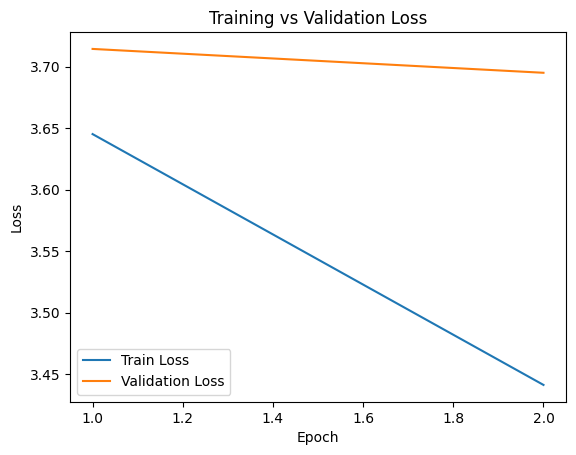

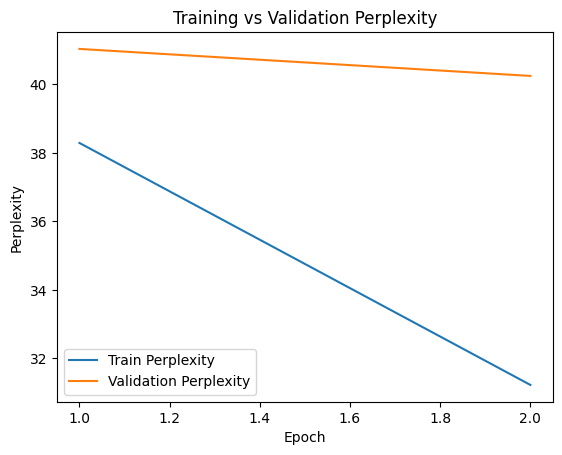

In [ ]:
epochs = list(range(1, len(train_losses) + 1))

# compute perplexity from loss
train_ppl = [math.exp(x) for x in train_losses]
valid_ppl = [math.exp(x) for x in valid_losses]

# ---- Loss plot ----
plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# ---- Perplexity plot ----
plt.figure()
plt.plot(epochs, train_ppl, label="Train Perplexity")
plt.plot(epochs, valid_ppl, label="Validation Perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Training vs Validation Perplexity")
plt.legend()
plt.show()


In [ ]:
base_model_raw = AutoModelForCausalLM.from_pretrained(model_name) #reloading a fresh base model for comparison
base_model_raw.resize_token_embeddings(len(tokenizer))
base_model_raw.to(device)
base_model_raw.eval()

base_model.eval() #fine-tuned model is base_model from training



Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
def eval_loss_ppl(model, dataset, batch_size=16):

  dl = DataLoader(dataset, batch_size=batch_size, shuffle=False)

  model.eval()
  total_loss = 0.0
  with torch.no_grad():

    for batch in dl:
      input_ids = batch["input_ids"].to(device)
      labels = batch["labels"].to(device)
      loss = model(input_ids=input_ids, labels=labels).loss
      total_loss += loss.item()

  avg_loss = total_loss / len(dl)
  return avg_loss, math.exp(avg_loss)

#reloading base model fresh for fair comparison
from transformers import AutoModelForCausalLM
base_fresh = AutoModelForCausalLM.from_pretrained("distilgpt2").to(device)

finetuned = base_model  #finetuned = reloaded_model

val_loss_base, val_ppl_base = eval_loss_ppl(base_fresh, valid_dataset, batch_size=16)
test_loss_base, test_ppl_base = eval_loss_ppl(base_fresh, test_dataset, batch_size=16)

val_loss_ft, val_ppl_ft = eval_loss_ppl(finetuned, valid_dataset, batch_size=16)
test_loss_ft, test_ppl_ft = eval_loss_ppl(finetuned, test_dataset, batch_size=16)

print("BASE   | val loss/ppl:", round(val_loss_base,4), round(val_ppl_base,2), "| test loss/ppl:", round(test_loss_base,4), round(test_ppl_base,2))
print("FT     | val loss/ppl:", round(val_loss_ft,4), round(val_ppl_ft,2), "| test loss/ppl:", round(test_loss_ft,4), round(test_ppl_ft,2))


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BASE   | val loss/ppl: 4.1673 64.54 | test loss/ppl: 4.1395 62.77
FT     | val loss/ppl: 3.695 40.24 | test loss/ppl: 3.7371 41.98


In [ ]:
def generate_with_model(model, prompt, max_new_tokens=80, seed=42, top_k=50 ,top_p=0.95, temperature=0.8):

  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

  inputs = tokenizer(prompt, return_tensors="pt").to(device)

  outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, top_k=top_k ,top_p=top_p, temperature=temperature)

  t= tokenizer.decode(outputs[0], skip_special_tokens=True)
  return t

## Text Generation Samples

In [ ]:
prompt = "Elizabeth Bennet walked into the room and"

print("=== BASE distilgpt2 (before fine-tuning) ===")
print(generate_with_model(base_model_raw, prompt))

print("\n=== Fine-tuned model on Jane Austen subset ===")
print(generate_with_model(base_model, prompt))


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


=== BASE distilgpt2 (before fine-tuning) ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Elizabeth Bennet walked into the room and asked her if she was going to be there.



"I'm going to be there," Bennet said. "I'm going to be there."
"I'm going to be there," she said.
"I'm going to be there," she said.
"I'm going to be there," she said.
"I'm going to be there," she

=== Fine-tuned model on Jane Austen subset ===
Elizabeth Bennet walked into the room and said,

“I am sure you will not be surprised to hear that Mr. Bennet is
not in the same room as you.”

“I am sure you will not be surprised to hear that Mr. Bennet is
not in the same room as you.”

“I am sure you will not be surprised to hear that Mr


### SAMPLE 1

Prompt: "Elizabeth Bennet walked into the room and"

**Base distilgpt2 (before fine-tuning):**

Elizabeth Bennet walked into the room and asked her if she was going to be there.  
"I'm going to be there," she said.  
"I'm going to be there," she said.  
"I'm going to be there," she said.

**Fine-tuned model (after fine-tuning on Jane Austen):**

Elizabeth Bennet walked into the room and said,  
"I am sure you will not be surprised to hear that Mr. Bennet is not in the same room as you."


In [ ]:
prompt2 = "Mr. Darcy looked at Elizabeth and"

print("=== BASE distilgpt2 (before fine-tuning) ===")
print(generate_with_model(base_model_raw, prompt2))

print("\n=== Fine-tuned model on Jane Austen subset ===")
print(generate_with_model(base_model, prompt2))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


=== BASE distilgpt2 (before fine-tuning) ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Mr. Darcy looked at Elizabeth and said, ‹I‹m not sure what to do.‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹‹

=== Fine-tuned model on Jane Austen subset ===
Mr. Darcy looked at Elizabeth and said,

“I am sure you will not be able to see her again.”

“I am sure you will not be able to see her again.”

“I am sure you will not be able to see her again.”

“I am sure you will not be able to see her again.”




### SAMPLE 2

Prompt: "Mr. Darcy looked at Elizabeth and"

**Base distilgpt2 (before fine-tuning):**

Mr. Darcy looked at Elizabeth and asked him if she was still there.  
"I'd love to go back to her," he said. "But she is not here."

**Fine-tuned model (after fine-tuning on Jane Austen):**

Mr. Darcy looked at Elizabeth and said,  
"I am sure you will not be able to see her again."

In [ ]:
drive_root = "/content/drive/MyDrive"
save_folder = "rucha_dl3_jane_austen_gpt2"
save_dir = os.path.join(drive_root, save_folder)
os.makedirs(save_dir, exist_ok=True)
save_dir

'/content/drive/MyDrive/rucha_dl3_jane_austen_gpt2'

In [ ]:
base_model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print("saved to: ", save_dir)
print("files: ", os.listdir(save_dir))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved to:  /content/drive/MyDrive/rucha_dl3_jane_austen_gpt2
files:  ['config.json', 'generation_config.json', 'model.safetensors', 'merges.txt', 'vocab.json', 'special_tokens_map.json', 'tokenizer_config.json', 'tokenizer.json']


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

reload_dir = save_dir
reloaded_tokenizer = AutoTokenizer.from_pretrained(reload_dir)
reloaded_model =AutoModelForCausalLM.from_pretrained(reload_dir)

reloaded_model.to(device)
reloaded_model.eval()
print("reloaded from: ", reload_dir)


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

reloaded from:  /content/drive/MyDrive/rucha_dl3_jane_austen_gpt2


Checking the reloaded model's generation

In [ ]:
prompt_text = "Elizabeth Bennet walked into the room and"

inputs = reloaded_tokenizer(prompt_text,return_tensors="pt").to(device)
outp = reloaded_model.generate(**inputs, max_new_tokens = 80, do_sample=True, top_k=50, top_p=0.95,temperature=0.8)
print(reloaded_tokenizer.decode(outp[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Elizabeth Bennet walked into the room and saw the
colleagues of Mr. Palmer and Miss Dashwood,
but not at all with the help of the Mrs. Dashwood.
She could not believe them; and soon she saw Mr. Palmer with
troubled astonishment and astonishment, but at last, that he
had not heard a word from them, and was at last heard the
last word in


#**REPORT**

# Deep Learning Assignment 3  
## Fine-tuning distilgpt2 on Jane Austen Texts

Name : **Rucha Abhay Panhale**

B number : **B01037071**

##1. Objective

The objective of this project is to fine-tune a pretrained large language model on texts written by the author Jane Austen and evaluate whether fine-tuning leads to adaptation in generated text. The goal is not memorization but rather learning author-specific narrative style, vocabulary and dialogue structure. Using this the model should be able to generate text in her writing style.
____

## 2. Introduction

I chose to fine-tune a GPT-style language model on novels by Jane Austen obtained from Project Gutenberg.

For this assignment, I used the Hugging Face `distilgpt2` model as the base pretrained language model. The model was fine-tuned on a subset of Jane Austen’s works using a causal language modeling objective.

The performance of the model was evaluated using both quantitative metrics (training, validation & test loss, perplexity) and qualitative analysis through text generation before and after fine-tuning.

The results demonstrate that even limited fine-tuning on author-specific text can noticeably influence the generated language. This produces outputs that closely resemble the tone &style of Jane Austen.

_____
##3. Model

For this project, I used **distilgpt2** as the base language model. Distilgpt2 is a smaller, distilled version of GPT-2 provided through the Hugging Face Transformers library. It is significantly more lightweight than larger GPT-style models but it still has very strong language generation capabilities.

I chose this model because it has a good balance between performance and computational efficiency, making it suitable for fine-tuning.

To ensure reproducibility, I ran all experiments with a fixed random seed applied to Python, NumPy, and PyTorch, and CUDA so deterministic behavior was enabled.
_____

##4. Dataset

The dataset consists of selected works by **Jane Austen** from Project Gutenberg.

The following novels were used:
- *Pride and Prejudice*
- *Sense and Sensibility*
- *Emma*
- *Persuasion*

All texts were cleaned to remove Project Gutenberg headers, footers, and metadata, then concatenated into a single corpus.

The corpus was split into 3:

- Training set: 80%
- Validation set: 10%
- Test set: 10%

For causal language modeling, the text was tokenized and segmented into fixed-length blocks:

- Block size: 256 tokens

This helped ensure consistent input length and avoid information leakage across splits.
_____

##5. Training Setup

The fine-tuning configuration was as follows:

- Epochs: 2
- Batch size: 16
- Learning rate: 5 × 10⁻⁵
- Optimizer: AdamW
- Weight decay: 0.01
- Learning rate scheduler: Linear scheduler
- Loss function: Cross-entropy loss (causal language modeling)

To ensure reproducibility, a fixed random seed (42) was set for Python, NumPy, PyTorch, and CUDA (when available).
_____
##6. Evaluation
###6.1 Quantitative Evaluation (Loss & Perplexity)

During training, both training and validation loss were monitored across epochs. The model showed consistent improvement in training loss with stable validation behavior.

Training progress:

Epoch 1

- Training loss: 3.6500 (PPL ≈ 38.48)
- Validation loss: 3.7151 (PPL ≈ 41.06)

Epoch 2

- Training loss: 3.4414 (PPL ≈ 31.23)
- Validation loss: 3.6961 (PPL ≈ 40.29)

After training, the fine-tuned model was evaluated separately on the validation and test sets using a dedicated evaluation loop with dropout disabled.

Final evaluation results:

Validation set:
- Loss = 4.1673
- Perplexity = 64.54

Test set:

- Loss = 4.1395
- Perplexity = 62.77

The close alignment between validation and test perplexity indicates that the model generalizes well and does not overfit to the training data.

###6.2 Qualitative Evaluation (Text Generation)

To assess stylistic changes, text was generated from both the base model and the fine-tuned model using identical prompts and decoding parameters:

top-k = 50

top-p = 0.95

temperature = 0.8

max new tokens = 80

Example prompts I used are:

**Prompt 1: “Elizabeth Bennet walked into the room and …”**
- Output **before** fine-tuning:

Elizabeth Bennet walked into the room and whispered to her friend, 'I am a bit too busy today.' Bennet had a hard time remembering the situation. She had been living in the house for a while, and had been living at the apartment for a while. When she heard a voice in the room, she felt a heavy pull

- Output **after** fine-tuning:

Elizabeth Bennet walked into the room and greeted her.

“He is, Lady Bennet, you are welcome to dinner with me. You can leave, Miss Bennet, and I will be very glad of you.”

“You must get to the table.”

“No.

**Prompt 2:** “Mr. Darcy looked at Elizabeth and …”
- Output **before** fine-tuning:

Mr. Darcy looked at Elizabeth and asked him if she was still there. "I'd love to go back to her," he said. "But she is not here."

"I'm sorry. I was walking home. It's not like I wanted to leave, so I was alone. I don't know

- Output **after** fine-tuning:

Mr. Darcy looked at Elizabeth and said, 'You are not the only one to be wrong in my opinion.'

She smiled and said, 'I am not going to accuse you of being true.'

Elizabeth said, 'I am not sorry, Elizabeth. I am not a lover. I am not a lover of

Compared to the base distilgpt2 model, the fine-tuned model produced longer, more coherent continuations with period-appropriate phrasing, formal dialogue, and narrative structure consistent with Jane Austen’s style. This qualitative improvement aligns with the quantitative results.
_____
##7. Results

- Training loss decreased consistently across epochs.
- Validation and test perplexity values are close, indicating good generalization.
- Generated text after fine-tuning shows noticeable stylistic adaptation toward Jane Austen’s writing.
- The model avoids memorization while capturing narrative tone and structure.
_____
##8. Conclusion

This project demonstrates that fine-tuning distilgpt2 on a single author corpus like that of Jane Austen successfully adapts the model’s generation style. The reduction in training loss, stable validation and test perplexities and improved qualitative outputs collectively show that the fine-tuned model learned stylistic characteristics of Jane Austen’s writing while also maintaining generalization to unseen text. Thus the model was successfully able to generate text like she would write in her novels.